# DD Project Simulation -- Sanofi FXa Case Study

**Goal:** replay the historic Sanofi Factor Xa (FXA) lead-optimisation campaign chronologically -- as if it were happening live, round by round -- combining ADMET fine-tuning, ligand-based affinity fine-tuning, and (eventually) cofolding + cofold-derived affinity, exactly as data would have arrived over 2001-2007.

**What's real vs placeholder in this notebook:**

| Piece | Status | Source |
|---|---|---|
| ADMET (LogD, solubility) fine-tuned predictions | **Real, reused** | Lewis's `federated_temporal_experiment_share` package -- not regenerated |
| Ligand-based (chemprop) affinity fine-tuned predictions | **Real, reused** | same package |
| MMP / SAR-cliff shortlist (cofolding candidates) | **Real, reused** | `cofolding_candidate_shortlist.ipynb`, re-run once here to get a saved CSV (rdkit MMP analysis -- deterministic cheminformatics, not a retrained model, so this does not fall under "don't regenerate ADMET/chemprop results") |
| MPO score | **New in this notebook** | built to match Neann's UCT/H3D seminar formulation (desirability functions combined by **weighted sum**, using `FXA/blueprint.csv`'s trend/threshold/weight columns) rather than the geometric-mean MPO used in the earlier mock analysis |
| Round 1 cofolding triage (stages 1-3) | **New, real, computed** | filters the fold-2 candidate pool down to a shortlist worth sending to ApherisFold |
| ApherisFold cofolding | **Placeholder** | needs an FXa target structure + an actual cofolding run |
| Cofold-derived affinity, MPO adjustment (stage 4) | **Placeholder** | needs the `apherisfold-qsar-explainability` Pairformer-embedding correlation model, which doesn't exist yet -- stage 4 below reads a results CSV once one exists |

Two affinity arms are carried side by side throughout, per Neann's request to test both once cofold-derived affinity exists:
- **Arm A -- ligand-based (chemprop, real):** Lewis's `foundation_finetune` (federated-initialised) model, with `scratch` and `chemeleon_finetune` as comparators.
- **Arm B -- cofold-derived (placeholder):** waits on a real cofolding run until stage 4 has something to read in.


In [1]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)

BASE = Path('.').resolve()
FXA_DIR = BASE / 'FXA'
FED_DIR = BASE.parent / 'federated_temporal_experiment_share'

# Ground-truth FXA dataset (identical file to Lewis's data/data.csv -- verified by md5 --
# so `_row_id` in his prediction files lines up positionally with this dataframe)
data = pd.read_csv(FXA_DIR / 'data.csv')
data.columns = ['DATE', 'CPD_ID', 'SERIES_ID', 'SMILES', 'pKi', 'LogD', 'Sol_uM']
data['DATE'] = pd.to_datetime(data['DATE'])
data['log10_Sol_uM'] = np.log10(data['Sol_uM'].clip(lower=0.1))

print(f"FXA dataset: {len(data)} compounds, {data.SERIES_ID.nunique()} series, "
      f"{data.DATE.min().date()} -> {data.DATE.max().date()}")
data.head(3)


FXA dataset: 1015 compounds, 15 series, 2001-07-31 -> 2007-09-19


        DATE CPD_ID       SERIES_ID                                                     SMILES       pKi   LogD  Sol_uM  log10_Sol_uM
0 2001-07-31  CPD_0  Aminoquinoline   Nc1nccc2ccc(CN3CC[C@H](NS(=O)(=O)c4cc5ncccc5s4)C3=O)cc12  6.563837  1.970   180.0      2.255273
1 2001-07-31  CPD_1  Ketopiperazine  O=C1CN(S(=O)(=O)c2cc3ccc(Cl)cc3s2)CCN1Cc1nc(-c2ccccc2)cs1  5.767258  6.490     9.7      0.986772
2 2001-07-31  CPD_2  Ketopiperazine   CC(C)(C)c1csc(CN2CCN(S(=O)(=O)c3cc4ccc(Cl)cc4s3)CC2=O)n1  6.119186  6.421    22.0      1.342423

## 1. Reuse Lewis's real per-compound temporal predictions (not regenerated)

`federated_temporal_experiment_share/results_snapshot.zip` already contains the completed run's
per-compound predictions (`prediction_points.csv.xz`). We expand it once, exactly the way Lewis's
own `RESULTS_WORKBOOK.ipynb` does on first open -- no chemprop training happens here.


In [2]:
snapshot_dir = FED_DIR / 'temporal_experiment'
if not (snapshot_dir / 'analysis' / 'prediction_points.csv.xz').exists():
    with zipfile.ZipFile(FED_DIR / 'results_snapshot.zip') as zf:
        zf.extractall(FED_DIR)
    print('Expanded results_snapshot.zip')
else:
    print('Already expanded')

preds_raw = pd.read_csv(snapshot_dir / 'analysis' / 'prediction_points.csv.xz')

# Arm A strategies of interest:
#   foundation_finetune  = fine-tuned from the supplied FEDERATED model  (the "federation" arm)
#   chemeleon_finetune   = fine-tuned from the public CheMeleon foundation model (best alternative on pKi)
#   scratch              = trained from scratch on the series alone (no pretraining)
ARM_A_STRATEGIES = ['scratch', 'chemeleon_finetune', 'foundation_finetune']

preds = preds_raw[
    (preds_raw.evaluation_scope == 'next_fold') &
    (preds_raw.strategy.isin(ARM_A_STRATEGIES))
].copy()

# Average over the 25 matched seed replicates per (row, strategy) -> one point prediction per
# compound per strategy per origin, matching how a real deployed model would be used.
preds_mean = (
    preds.groupby(['_row_id', 'origin', 'strategy'], as_index=False)
    .agg(
        pKi_pred=('pKi__predicted', 'mean'),
        LogD_pred=('LogD (pH 7.40)__predicted', 'mean'),
        LogSol_pred=('log10_solubility_uM__predicted', 'mean'),
    )
)

# Attach ground truth via the row_id <-> data.csv positional join (verified identical file/order)
preds_mean = preds_mean.merge(
    data.reset_index().rename(columns={'index': '_row_id'}),
    on='_row_id', how='left'
)

print(f"{len(preds_mean)} (compound x origin x strategy) prediction rows, reused from Lewis's run")
preds_mean.head(3)


Already expanded
2439 (compound x origin x strategy) prediction rows, reused from Lewis's run


   _row_id  origin             strategy  pKi_pred  LogD_pred  LogSol_pred       DATE   CPD_ID SERIES_ID                                                                   SMILES       pKi   LogD   Sol_uM  log10_Sol_uM
0      202       1   chemeleon_finetune  6.937021  -1.940779     4.120885 2002-11-27  CPD_202   Azole12  CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCN(CCO)C3=O)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1  7.325344 -3.356  30000.0      4.477121
1      202       1  foundation_finetune  7.161248  -3.375200     4.931429 2002-11-27  CPD_202   Azole12  CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCN(CCO)C3=O)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1  7.325344 -3.356  30000.0      4.477121
2      202       1              scratch  6.693910  -0.939999     4.026191 2002-11-27  CPD_202   Azole12  CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCN(CCO)C3=O)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1  7.325344 -3.356  30000.0      4.477121

## 2. Campaign rounds -- Lewis's rolling origins, reused as-is

Lewis split the campaign into 5 chronological folds and defined 4 rolling origins
(origin *i* = trained on folds 1..*i*, evaluated on fold *i*+1, the "next_fold" scope).
These boundaries come straight from his `experiment_manifest.json` -- not recomputed.


In [3]:
# From federated_temporal_experiment_share/temporal_experiment/experiment_manifest.json ("folds")
FOLD_BOUNDARIES = pd.DataFrame([
    {'temporal_fold': 1, 'date_start': '2001-07-31', 'date_end': '2002-11-26', 'n_rows': 202},
    {'temporal_fold': 2, 'date_start': '2002-11-27', 'date_end': '2003-05-13', 'n_rows': 204},
    {'temporal_fold': 3, 'date_start': '2003-05-15', 'date_end': '2003-08-18', 'n_rows': 205},
    {'temporal_fold': 4, 'date_start': '2003-08-22', 'date_end': '2004-08-06', 'n_rows': 206},
    {'temporal_fold': 5, 'date_start': '2004-08-10', 'date_end': '2007-09-19', 'n_rows': 198},
])
FOLD_BOUNDARIES['date_start'] = pd.to_datetime(FOLD_BOUNDARIES['date_start'])
FOLD_BOUNDARIES['date_end'] = pd.to_datetime(FOLD_BOUNDARIES['date_end'])

# Round r = origin r, "what would we have predicted for fold r+1, knowing only folds 1..r?"
rounds = pd.DataFrame({'round': [1, 2, 3, 4]})
rounds['origin_known_through_fold'] = rounds['round']
rounds['predicts_fold'] = rounds['round'] + 1
rounds = rounds.merge(
    FOLD_BOUNDARIES.add_prefix('predicted_'),
    left_on='predicts_fold', right_on='predicted_temporal_fold'
)
rounds[['round', 'origin_known_through_fold', 'predicts_fold', 'predicted_date_start', 'predicted_date_end', 'predicted_n_rows']]


   round  origin_known_through_fold  predicts_fold predicted_date_start predicted_date_end  predicted_n_rows
0      1                          1              2           2002-11-27         2003-05-13               204
1      2                          2              3           2003-05-15         2003-08-18               205
2      3                          3              4           2003-08-22         2004-08-06               206
3      4                          4              5           2004-08-10         2007-09-19               198

## 3. MPO score -- desirability functions combined by weighted sum

This follows the formulation from Neann's H3D/UCT seminar (27 Aug 2026): each property is scaled
through a **desirability function** that plateaus once "good enough" is reached (e.g. pKi desirability
stops increasing past 8.5 -- chasing more potency beyond that buys nothing), then the scaled properties
are combined as a **weighted sum**, not a geometric mean (the earlier mock analysis used a geometric
mean; this corrects that to match what Neann actually described).

Thresholds and weights are read from `FXA/blueprint.csv`, already sitting in this project:
- `TREND = H` ("higher is better"): desirability ramps 0->1 from `LTV` to `HTV`.
- `TREND = V` (sweet-spot / valley -- e.g. LogD): desirability is 1 inside `[LTV, HTV]` and decays
  linearly to 0 over an equal-width margin outside the band on either side.


In [4]:
blueprint = pd.read_csv(FXA_DIR / 'blueprint.csv')
print(blueprint.to_string(index=False))

def desirability(value, trend, ltv, htv):
    value = np.asarray(value, dtype=float)
    if trend == 'H':
        d = (value - ltv) / (htv - ltv)
        return np.clip(d, 0.0, 1.0)
    elif trend == 'V':
        band = htv - ltv
        d = np.ones_like(value)
        below = value < ltv
        above = value > htv
        d[below] = np.clip(1 - (ltv - value[below]) / band, 0.0, 1.0)
        d[above] = np.clip(1 - (value[above] - htv) / band, 0.0, 1.0)
        return d
    else:
        raise ValueError(f'Unknown trend {trend!r}')

PROPERTY_COLUMN = {
    'pKi': 'pKi',
    'Solubility (pH 7.40) (uM)': 'Sol_uM',
    'LogD (pH 7.40)': 'LogD',
}

def mpo_score(df, column_map=PROPERTY_COLUMN):
    """Weighted-sum MPO. `column_map` lets us point at either ground-truth or predicted columns."""
    total_weight = blueprint['WEIGHT'].sum()
    score = np.zeros(len(df))
    for _, row in blueprint.iterrows():
        col = column_map[row['PROPERTIES']]
        d = desirability(df[col].values, row['TREND'], row['LTV'], row['HTV'])
        score += row['WEIGHT'] * d
    return score / total_weight

# sanity check on ground truth
data['MPO_truth'] = mpo_score(data.rename(columns={'pKi': 'pKi', 'Sol_uM': 'Sol_uM', 'LogD': 'LogD'}))
print()
print('Ground-truth MPO -- distribution:')
print(data['MPO_truth'].describe())

# preds_mean was merged with `data` before MPO_truth existed on it -- attach it now so later
# cells can score predicted vs. ground-truth MPO side by side for the same compound.
preds_mean['MPO_truth'] = mpo_score(preds_mean.rename(columns={'pKi': 'pKi', 'Sol_uM': 'Sol_uM', 'LogD': 'LogD'}))


               PROPERTIES TREND  LTV   HTV  WEIGHT
                      pKi     H  8.5   9.0       3
Solubility (pH 7.40) (uM)     H 50.0 100.0       1
           LogD (pH 7.40)     V  1.5   3.5       1

Ground-truth MPO -- distribution:
count    1015.000000
mean        0.279135
std         0.151170
min         0.000000
25%         0.200000
50%         0.215600
75%         0.362300
max         1.000000
Name: MPO_truth, dtype: float64


## 4. Round-by-round campaign table (Arm A -- ligand-based, real, reused)

For each round, score the compounds due to appear in the *next* fold using each strategy's
fine-tuned predictions (as if this were the model available to the project team at that point in
the campaign), and compare against the ground-truth MPO once the fold's true values are known.


In [5]:
def predicted_mpo_from_logsol(sub):
    """Predictions are on pKi, LogD, and log10(solubility); invert log-solubility before scoring
    so the same desirability function (defined on raw uM) applies to predicted and true values alike."""
    tmp = sub.copy()
    tmp['Sol_uM_pred'] = 10 ** tmp['LogSol_pred']
    return mpo_score(tmp, column_map={
        'pKi': 'pKi_pred', 'Solubility (pH 7.40) (uM)': 'Sol_uM_pred', 'LogD (pH 7.40)': 'LogD_pred',
    })

campaign_rows = []
for _, r in rounds.iterrows():
    round_preds = preds_mean[preds_mean.origin == r['round']].copy()
    round_preds['MPO_pred'] = predicted_mpo_from_logsol(round_preds)
    for strategy, grp in round_preds.groupby('strategy'):
        campaign_rows.append({
            'round': int(r['round']),
            'predicts_fold': int(r['predicts_fold']),
            'fold_start': r['predicted_date_start'],
            'fold_end': r['predicted_date_end'],
            'strategy': strategy,
            'n_compounds': len(grp),
            'MPO_pred_mean': grp['MPO_pred'].mean(),
            'MPO_truth_mean': grp['MPO_truth'].mean(),
            'pKi_RMSE': np.sqrt(np.mean((grp['pKi_pred'] - grp['pKi']) ** 2)),
        })

campaign = pd.DataFrame(campaign_rows).sort_values(['round', 'strategy'])
campaign


    round  predicts_fold fold_start   fold_end             strategy  n_compounds  MPO_pred_mean  MPO_truth_mean  pKi_RMSE
0       1              2 2002-11-27 2003-05-13   chemeleon_finetune          204       0.272402        0.234242  0.779825
1       1              2 2002-11-27 2003-05-13  foundation_finetune          204       0.235935        0.234242  0.718428
2       1              2 2002-11-27 2003-05-13              scratch          204       0.279964        0.234242  0.795818
3       2              3 2003-05-15 2003-08-18   chemeleon_finetune          205       0.284605        0.273722  1.177902
4       2              3 2003-05-15 2003-08-18  foundation_finetune          205       0.278034        0.273722  1.277601
5       2              3 2003-05-15 2003-08-18              scratch          205       0.251588        0.273722  1.244416
6       3              4 2003-08-22 2004-08-06   chemeleon_finetune          206       0.291659        0.267183  1.025491
7       3              4

In [6]:
# Flag rounds that contain one of the already-shortlisted SAR-cliff showcase compounds
shortlist = pd.read_csv(BASE / 'cofolding_candidate_shortlist.csv')
showcase_cpds = set(shortlist.CPD_A) | set(shortlist.CPD_B)

data_with_round = data.merge(
    FOLD_BOUNDARIES[['temporal_fold', 'date_start', 'date_end']], how='cross'
)
data_with_round = data_with_round[
    (data_with_round.DATE >= data_with_round.date_start) & (data_with_round.DATE <= data_with_round.date_end)
]
showcase_by_fold = (
    data_with_round[data_with_round.CPD_ID.isin(showcase_cpds)]
    .groupby('temporal_fold')['CPD_ID'].apply(list)
)
print('Showcase (MMP shortlist) compounds land in these folds:')
print(showcase_by_fold)


Showcase (MMP shortlist) compounds land in these folds:
temporal_fold
1             [CPD_4, CPD_5, CPD_82, CPD_116, CPD_169]
2    [CPD_213, CPD_332, CPD_335, CPD_337, CPD_342, ...
3    [CPD_416, CPD_421, CPD_457, CPD_458, CPD_519, ...
4    [CPD_650, CPD_686, CPD_687, CPD_754, CPD_775, ...
5                                   [CPD_976, CPD_979]
Name: CPD_ID, dtype: object


## 5. Round 1, stage 1 -- 2D QSPR predictions for the first time split

The first round-level pipeline pass, run for **round 1 only** (predicting fold 2). We'll repeat
stages 1-4 for round 2 once we've seen how round 1's cofolding results look.

Stage 1 is what's already reused above, pulled per-compound for round 1: each of the 204 compounds
due in fold 2 gets a consensus 2D QSPR (chemprop) potency prediction plus ADMET (LogD, solubility),
averaged across the three Arm-A strategies (we don't bet on a single strategy here -- pKi and ADMET
have different winners per Lewis's north-star finding).


In [7]:
def build_consensus_predictions(round_num):
    """Per-compound consensus 2D QSPR + ADMET prediction for a round: average each property's
    chemprop prediction across the three Arm-A strategies."""
    sub = preds_mean[preds_mean.origin == round_num]
    consensus = (
        sub.groupby(['CPD_ID', 'SMILES', 'SERIES_ID'], as_index=False)
        .agg(
            pKi_pred=('pKi_pred', 'mean'),
            LogD_pred=('LogD_pred', 'mean'),
            LogSol_pred=('LogSol_pred', 'mean'),
            MPO_truth=('MPO_truth', 'first'),
        )
    )
    consensus['Sol_uM_pred'] = 10 ** consensus['LogSol_pred']
    return consensus

round1_qspr = build_consensus_predictions(1)
print(f"Round 1, stage 1: {len(round1_qspr)} compounds due in fold 2 -- 2D QSPR (chemprop) + ADMET "
      f"predictions, real, reused from Lewis's foundation_finetune / chemeleon_finetune / scratch runs")
round1_qspr.head(5)


Round 1, stage 1: 204 compounds due in fold 2 -- 2D QSPR (chemprop) + ADMET predictions, real, reused from Lewis's foundation_finetune / chemeleon_finetune / scratch runs


    CPD_ID                                                                   SMILES SERIES_ID  pKi_pred  LogD_pred  LogSol_pred  MPO_truth   Sol_uM_pred
0  CPD_202  CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCN(CCO)C3=O)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1   Azole12  6.930727  -2.085326     4.359501        0.2  22882.393058
1  CPD_203   CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCN(CCO)CC3)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1   Azole12  6.775856  -1.770349     4.663907        0.2  46121.850954
2  CPD_204                  CC(C)N1CC(CNC(=O)c2cc3ccccc3n2Cc2cc(-c3ccc(Cl)s3)on2)C1    Indole  6.950969   2.379740     2.027466        0.4    106.528620
3  CPD_205     CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCC(O)CC3)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1   Azole12  6.858463  -1.730341     4.198077        0.2  15778.894581
4  CPD_206    CC(C)N1CCC(NC(=O)c2cc(C(=O)N3CCC(CO)CC3)nn2Cc2cc(-c3ccc(Cl)s3)on2)CC1   Azole12  6.844793  -1.645193     4.334892        0.2  21621.832103

## 6. Round 1, stage 2 -- MPO score and visualization

Score every round-1 candidate with the weighted-sum desirability MPO from section 3, then look at
the distribution before deciding a cutoff for cofolding.


Round 1, stage 2: predicted MPO -- distribution:
count    204.000000
mean       0.264127
std        0.077925
min        0.140901
25%        0.200000
50%        0.217872
75%        0.331034
max        0.400000
Name: MPO_pred, dtype: float64


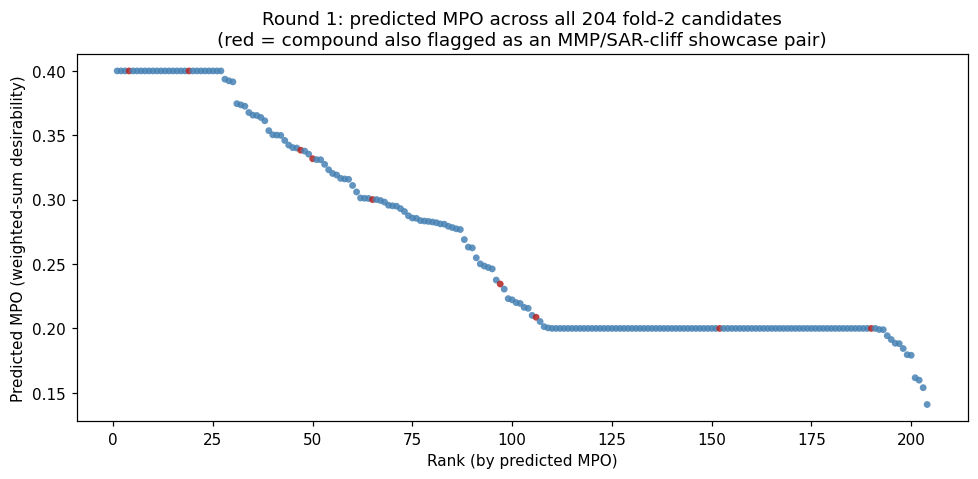

In [8]:
round1_qspr['MPO_pred'] = mpo_score(round1_qspr, column_map={
    'pKi': 'pKi_pred', 'Solubility (pH 7.40) (uM)': 'Sol_uM_pred', 'LogD (pH 7.40)': 'LogD_pred',
})
round1_qspr = round1_qspr.sort_values('MPO_pred', ascending=False).reset_index(drop=True)
round1_qspr['MPO_pred_rank'] = round1_qspr.index + 1

showcase_r1 = set(showcase_by_fold.get(2, []))  # fold 2 is what round 1 predicts
round1_qspr['is_sar_cliff'] = round1_qspr['CPD_ID'].isin(showcase_r1)

print('Round 1, stage 2: predicted MPO -- distribution:')
print(round1_qspr['MPO_pred'].describe())

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = np.where(round1_qspr['is_sar_cliff'], 'firebrick', 'steelblue')
ax.scatter(round1_qspr['MPO_pred_rank'], round1_qspr['MPO_pred'], c=colors, s=20, alpha=0.85,
           edgecolors='none')
ax.set_xlabel('Rank (by predicted MPO)')
ax.set_ylabel('Predicted MPO (weighted-sum desirability)')
ax.set_title('Round 1: predicted MPO across all 204 fold-2 candidates\n'
              '(red = compound also flagged as an MMP/SAR-cliff showcase pair)')
fig.tight_layout()
plt.show()


### 6a. MPO components -- desirability function per property

Same style as slides 15-16 of your H3D talk: the shape of each property's desirability function
(how a raw value gets scaled to 0-1 before the weighted sum), and where round 1's predicted
compounds actually sit in that 3-property space relative to the MPO score.


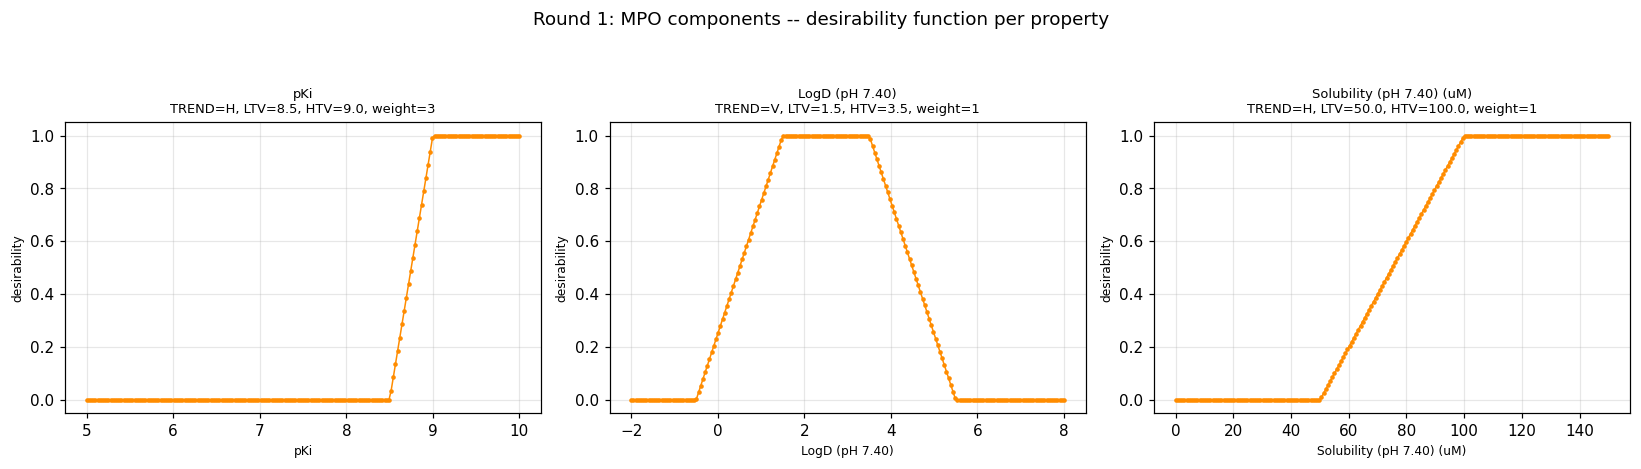

In [9]:
PROP_RANGES = {
    'pKi': np.linspace(5, 10, 200),
    'LogD (pH 7.40)': np.linspace(-2, 8, 200),
    'Solubility (pH 7.40) (uM)': np.linspace(0, 150, 200),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (prop, xs) in zip(axes, PROP_RANGES.items()):
    row = blueprint[blueprint.PROPERTIES == prop].iloc[0]
    ys = desirability(xs, row['TREND'], row['LTV'], row['HTV'])
    ax.plot(xs, ys, color='darkorange', marker='o', markersize=2, linewidth=1)
    ax.set_title(f"{prop}\nTREND={row['TREND']}, LTV={row['LTV']}, HTV={row['HTV']}, weight={row['WEIGHT']}",
                 fontsize=8.5)
    ax.set_xlabel(prop, fontsize=8)
    ax.set_ylabel('desirability', fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

fig.suptitle('Round 1: MPO components -- desirability function per property', y=1.05)
fig.tight_layout()
plt.show()


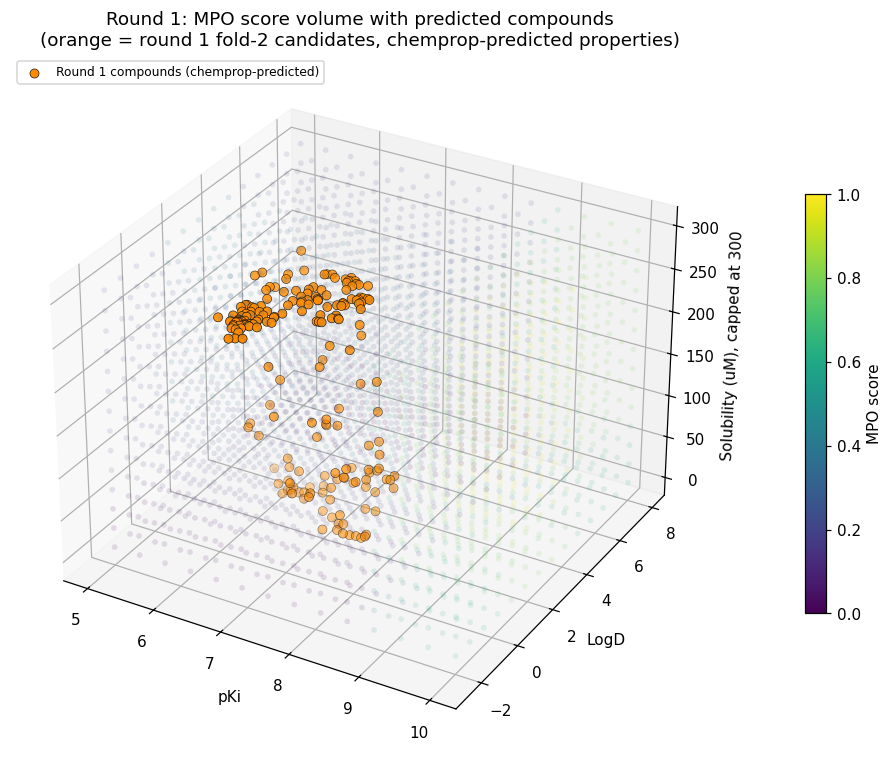

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the '3d' projection
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Cap the solubility axis: a handful of chemprop predictions extrapolate to
# implausibly high uM values (out-of-distribution), and letting those set the
# axis range squashes the whole sweet-spot region (HTV=100 uM) into a sliver.
sol_axis_max = min(300.0, max(150.0, round1_qspr['Sol_uM_pred'].quantile(0.9)))
pki_grid = np.linspace(5, 10, 14)
logd_grid = np.linspace(-2, 8, 14)
sol_grid = np.linspace(0, sol_axis_max, 14)
PKI, LOGD, SOL = np.meshgrid(pki_grid, logd_grid, sol_grid, indexing='ij')
grid_df = pd.DataFrame({'pKi': PKI.ravel(), 'LogD': LOGD.ravel(), 'Sol_uM': SOL.ravel()})
grid_df['MPO'] = mpo_score(grid_df, column_map={
    'pKi': 'pKi', 'Solubility (pH 7.40) (uM)': 'Sol_uM', 'LogD (pH 7.40)': 'LogD',
})

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(grid_df['pKi'], grid_df['LogD'], grid_df['Sol_uM'], c=grid_df['MPO'],
           cmap='viridis', vmin=0, vmax=1, alpha=0.12, s=14, linewidths=0)
ax.scatter(round1_qspr['pKi_pred'], round1_qspr['LogD_pred'],
           round1_qspr['Sol_uM_pred'].clip(upper=sol_axis_max),
           c='darkorange', edgecolors='black', linewidths=0.4, s=35,
           label='Round 1 compounds (chemprop-predicted)')
# Colorbar from its own fully-opaque ScalarMappable -- fig.colorbar() otherwise
# inherits the background scatter's alpha=0.12 and renders an almost-invisible bar.
sm = cm.ScalarMappable(cmap='viridis', norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('MPO score')
ax.set_xlabel('pKi')
ax.set_ylabel('LogD')
ax.set_zlabel(f'Solubility (uM), capped at {sol_axis_max:.0f}')
ax.set_title('Round 1: MPO score volume with predicted compounds\n'
             '(orange = round 1 fold-2 candidates, chemprop-predicted properties)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()


## 7. Round 1, stage 3 -- select compounds for cofolding

Funnel step: only a subset of the 204 candidates is worth the cost of an actual cofolding run.
Selection = top-20 by predicted MPO, unioned with any compound already flagged as an MMP/SAR-cliff
showcase pair landing in fold 2 -- those are exactly the compounds where a 2D-only model is most
likely to be wrong, so cofolding's structural signal matters most.


In [11]:
def select_cofolding_candidates(qspr_df, predicts_fold, top_n=20):
    """qspr_df must already be sorted by MPO_pred descending with MPO_pred_rank set
    (as round1_qspr is after stage 2). Returns one row per selected compound with the
    reason it was selected."""
    top_mpo_cpds = set(qspr_df.head(top_n)['CPD_ID'])
    sar_cliff_cpds = set(showcase_by_fold.get(predicts_fold, []))

    def reason(cpd):
        if cpd in top_mpo_cpds and cpd in sar_cliff_cpds:
            return 'top_MPO+SAR_cliff'
        if cpd in top_mpo_cpds:
            return 'top_MPO'
        return 'SAR_cliff'

    selected = qspr_df[qspr_df.CPD_ID.isin(top_mpo_cpds | sar_cliff_cpds)].copy()
    selected['selection_reason'] = selected['CPD_ID'].apply(reason)
    return selected.sort_values('MPO_pred_rank')

round1_candidates = select_cofolding_candidates(round1_qspr, predicts_fold=2, top_n=20)
round1_candidates['round'] = 1
round1_candidates['predicts_fold'] = 2

print(f"Round 1, stage 3: {len(round1_candidates)} of {len(round1_qspr)} compounds selected for cofolding")
print(round1_candidates['selection_reason'].value_counts().to_string())

OUT_COLS = ['CPD_ID', 'SERIES_ID', 'SMILES', 'pKi_pred', 'LogD_pred', 'Sol_uM_pred',
            'MPO_pred', 'MPO_pred_rank', 'MPO_truth', 'selection_reason', 'round', 'predicts_fold']
round1_candidates[OUT_COLS].to_csv(BASE / 'round1_cofolding_candidates.csv', index=False)
round1_candidates[OUT_COLS]


Round 1, stage 3: 27 of 204 compounds selected for cofolding
selection_reason
top_MPO              18
SAR_cliff             7
top_MPO+SAR_cliff     2


      CPD_ID      SERIES_ID                                                                                 SMILES  pKi_pred  LogD_pred  Sol_uM_pred  MPO_pred  MPO_pred_rank  MPO_truth   selection_reason  round  predicts_fold
0    CPD_247         Indole                               CC(C)N1CCC(NC(=O)c2nc3cccnc3n2Cc2cc(-c3ccc(Cl)s3)on2)CC1  7.071394   1.761976   198.100585  0.400000              1     0.4000            top_MPO      1              2
1    CPD_383         Indole                      COCCOc1cc2cc(C(=O)NC3CCN(C(C)C)CC3)n(Cc3cc(-c4ccc(Cl)s4)on3)c2cn1  7.765531   1.648132   394.834568  0.400000              2     0.3106            top_MPO      1              2
2    CPD_327         Indole                               CC(C)N1CCC(NC(=O)c2cc3ncccc3n2Cc2cc(-c3ccc(Cl)s3)on2)CC1  7.437293   1.669502   323.466373  0.400000              3     0.3186            top_MPO      1              2
3    CPD_332         Indole     CC(OC(=O)OC1CCCCC1)OC(=O)c1ccc2c(c1)cc(C(=O)NC1CCN(C(C)C)CC1)n2C

## 8. Round 1, stage 4 -- read in cofolding, adjust MPO, finalize round 1 (placeholder)

Not run yet -- there's no real cofolding output for `round1_cofolding_candidates.csv` yet. Once
you've run ApherisFold (and, eventually, the `apherisfold-qsar-explainability` correlation model)
on those 27 compounds and exported a results CSV (`CPD_ID`, `pKi_cofold`), call
`adjust_mpo_with_cofolding(...)` below: it swaps the cofold-derived pKi in for the chemprop-predicted
one wherever it's available, recomputes MPO, and re-ranks -- so you can see directly whether
cofolding moved any compound in or out of the selection versus stage 3's chemprop-only ranking. Any
compound cofolding wasn't run on (or that failed) just keeps its chemprop-predicted pKi.


In [12]:
def adjust_mpo_with_cofolding(cofold_results_path):
    """Stage 4: read real cofold-derived affinity results and finalize round 1.
    cofold_results_path: CSV with at least CPD_ID and pKi_cofold, e.g. exported after running
    ApherisFold + apherisfold-qsar-explainability on round1_cofolding_candidates.csv.
    Returns round1_candidates with the cofold-adjusted pKi, MPO, rank, and how much each
    compound's rank moved relative to the chemprop-only stage 3 ranking."""
    cofold_results = pd.read_csv(cofold_results_path)
    merged = round1_candidates.merge(cofold_results[['CPD_ID', 'pKi_cofold']], on='CPD_ID', how='left')
    merged['pKi_final'] = merged['pKi_cofold'].fillna(merged['pKi_pred'])
    merged['MPO_adjusted'] = mpo_score(merged, column_map={
        'pKi': 'pKi_final', 'Solubility (pH 7.40) (uM)': 'Sol_uM_pred', 'LogD (pH 7.40)': 'LogD_pred',
    })
    merged = merged.sort_values('MPO_adjusted', ascending=False).reset_index(drop=True)
    merged['MPO_adjusted_rank'] = merged.index + 1
    merged['rank_change'] = merged['MPO_pred_rank'] - merged['MPO_adjusted_rank']
    return merged

# Not run -- call once real cofolding results exist, e.g.:
#   round1_final = adjust_mpo_with_cofolding('round1_cofold_results.csv')
#   round1_final[['CPD_ID', 'MPO_pred_rank', 'MPO_adjusted_rank', 'rank_change']]
print('Stage 4 defined, not run: no cofolding results for round1_cofolding_candidates.csv yet.')


Stage 4 defined, not run: no cofolding results for round1_cofolding_candidates.csv yet.


## 9. Campaign timeline -- Arm A predicted vs. ground truth MPO, by round

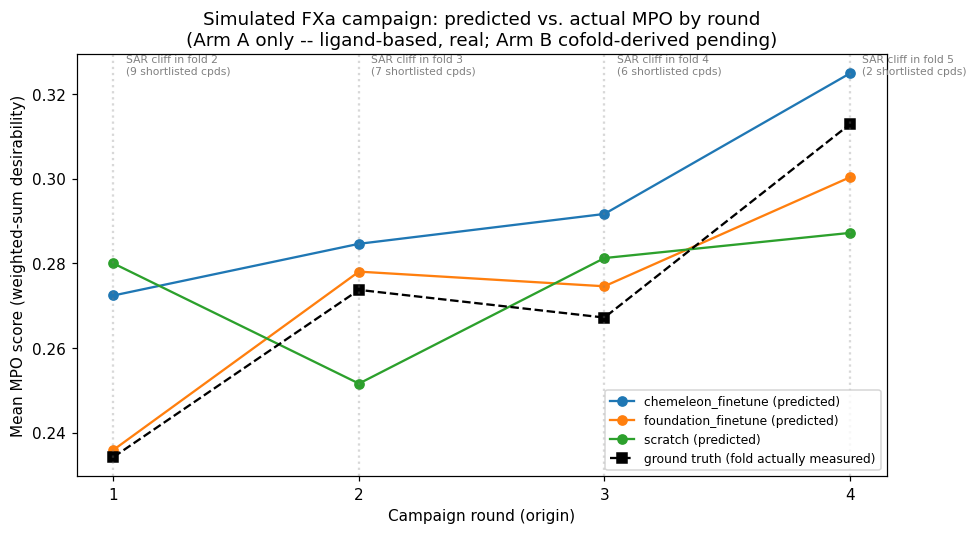

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for strategy, grp in campaign.groupby('strategy'):
    ax.plot(grp['round'], grp['MPO_pred_mean'], marker='o', label=f'{strategy} (predicted)')

truth_by_round = campaign.groupby('round')['MPO_truth_mean'].first()
ax.plot(truth_by_round.index, truth_by_round.values, marker='s', linestyle='--',
        color='black', label='ground truth (fold actually measured)')

for fold, cpds in showcase_by_fold.items():
    r = fold - 1  # this fold is predicted by round = fold - 1
    if r in campaign['round'].values:
        ax.axvline(r, color='grey', alpha=0.3, linestyle=':')
        ax.annotate(f'SAR cliff in fold {fold}\n({len(cpds)} shortlisted cpds)',
                    xy=(r, ax.get_ylim()[1]), xytext=(r + 0.05, ax.get_ylim()[1]),
                    fontsize=7, color='grey', va='top')

ax.set_xlabel('Campaign round (origin)')
ax.set_ylabel('Mean MPO score (weighted-sum desirability)')
ax.set_title('Simulated FXa campaign: predicted vs. actual MPO by round\n(Arm A only -- ligand-based, real; Arm B cofold-derived pending)')
ax.set_xticks(campaign['round'].unique())
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Summary & next steps

**Real, reused in this notebook:** ADMET (LogD, solubility) and ligand-based affinity predictions
from Lewis's completed chemprop run, for 3 strategies (`scratch`, `chemeleon_finetune`,
`foundation_finetune`) across all 4 rolling origins; the MMP/SAR-cliff shortlist (re-run once here
from the existing notebook's logic -- deterministic cheminformatics, no model retraining); ground
truth FXA data; a new weighted-sum MPO scorer matching Neann's UCT seminar formulation; and a full
round 1 pipeline (stages 1-3) -- 2D QSPR + ADMET predictions, MPO scoring and visualization, and
cofolding candidate selection -- saved to `round1_cofolding_candidates.csv` (27 of 204 compounds).

**Placeholder, not run:** stage 4 (`adjust_mpo_with_cofolding`) -- reading in real ApherisFold /
apherisfold-qsar-explainability cofolding results for those 27 compounds, adjusting their MPO, and
finalizing round 1's selection.

**Concrete next steps:**
1. Run ApherisFold cofolding on `round1_cofolding_candidates.csv` (real SMILES, ready to send), and
   eventually the `apherisfold-qsar-explainability` correlation model to turn that into a pKi.
2. Export the results as a CSV (`CPD_ID`, `pKi_cofold`) and call `adjust_mpo_with_cofolding(...)` to
   see whether cofolding would have changed which compounds got carried into round 2.
3. Once round 1 is finalized, repeat stages 1-4 for round 2 (`build_consensus_predictions(2)`,
   `select_cofolding_candidates(..., predicts_fold=3)`, etc.) the same way.
4. Longer term, compare Arm A vs. Arm B directly across the whole campaign -- per Neann's request,
   both need to be tested, not just one.
